<h1>Librerias Necesarias<h1>

In [2]:
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h1>1.Cargamos los datos<h1>

In [4]:
# 1. Cargar datos
data = pd.read_csv('sensor_readings_24.csv', header=None)
data.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.438,0.498,3.625,3.645,5.0,2.918,5.0,2.351,2.332,2.643,...,0.593,0.502,0.493,0.504,0.445,0.431,0.444,0.440,0.429,Slight-Right-Turn
1,0.438,0.498,3.625,3.648,5.0,2.918,5.0,2.637,2.332,2.649,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.443,0.429,Slight-Right-Turn
2,0.438,0.498,3.625,3.629,5.0,2.918,5.0,2.637,2.334,2.643,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.446,0.429,Slight-Right-Turn
3,0.437,0.501,3.625,3.626,5.0,2.918,5.0,2.353,2.334,2.642,...,0.593,0.502,0.493,0.504,0.449,0.431,0.444,0.444,0.429,Slight-Right-Turn
4,0.438,0.498,3.626,3.629,5.0,2.918,5.0,2.640,2.334,2.639,...,0.592,0.502,0.493,0.504,0.449,0.431,0.444,0.441,0.429,Slight-Right-Turn


<p>Lo que estoy haciendo aqui es lo seguiente:<p>

<p>Cargamos el dataset sensor_readings_24.csv sin encabezados (header=None), ya que los datos no tienen nombres de columnas.<p>

<h1>2. Preprocesamiento<h1>

In [5]:
# 2. Preprocesamiento
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

<p>Lo que estoy haciendo aqui es lo seguiente:<p>

<p>Separa las características (X) de la variable objetivo (y):<p>

    X: Todas las columnas excepto la última.

    y: La última columna (las etiquetas de clasificación).

In [6]:
# Codificar etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

<p>Lo que estoy haciendo aqui es lo seguiente:<p>

<p>Convierte las etiquetas en valores numéricos (si son categóricas).
Ejemplo:<p>

    "Rojo", "Azul", "Verde" → 0, 1, 2.

In [7]:
# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

<p>Lo que estoy haciendo aqui es lo seguiente:<p>

 <p>Dividimos los datos en entrenamiento (80%) y prueba (20%), asegurando que todas las clases estén balanceadas (stratify=y_encoded).<p>

In [8]:
# Normalizar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<p>Lo que estoy haciendo aqui es lo seguiente:<p>

<p>Vamos a estandalizar los datos (media = 0, desviación estándar = 1) para mejorar la estabilidad del entrenamiento.<p>

<h1>3. Definir modelo en TensorFlow<h1>

In [9]:
# 3. Definir modelo en TensorFlow
model = keras.Sequential([
    keras.layers.Dense(100, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(len(np.unique(y_encoded)), activation='softmax')  # Capa de salida
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


<p>Lo que estoy haciendo aqui es lo seguiente:<p>

<p>Crea una red neuronal con:<p>

    Capa oculta 1: 100 neuronas, activación ReLU.

    Capa oculta 2: 50 neuronas, activación ReLU.

    Capa de salida: N neuronas (una por clase), activación Softmax (para clasificación multiclase).

In [10]:
# Compilar modelo
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

<p>Lo que estoy haciendo aqui es lo seguiente:<p>

 <p>Configura el modelo:<p>

    Optimizador: Adam (ajusta pesos automáticamente para mejorar el aprendizaje).

    Función de pérdida: sparse_categorical_crossentropy (porque las etiquetas son enteros).

    Métrica: Precisión (accuracy).

<h1>4. Entrenamiento<h1>

In [11]:
# 4. Entrenamiento
history = model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5567 - loss: 1.0252 - val_accuracy: 0.7529 - val_loss: 0.6165
Epoch 2/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7575 - loss: 0.5978 - val_accuracy: 0.7986 - val_loss: 0.5126
Epoch 3/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8291 - loss: 0.4756 - val_accuracy: 0.8284 - val_loss: 0.4544
Epoch 4/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8455 - loss: 0.4238 - val_accuracy: 0.8513 - val_loss: 0.4201
Epoch 5/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8810 - loss: 0.3578 - val_accuracy: 0.8673 - val_loss: 0.3735
Epoch 6/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8896 - loss: 0.3295 - val_accuracy: 0.8856 - val_loss: 0.3539
Epoch 7/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9009 - loss: 0.3029 - val_accuracy: 0.8764 - val_loss: 0.3356
Epoch 8/50
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9176 - loss: 0.2613 - val_accuracy: 0.

<p>Lo que estoy haciendo aqui es lo seguiente:<p>

<p>Entrena el modelo durante 50 épocas con:<p>

    Minilotes de 32 muestras (batch_size=32).

    10% de los datos de entrenamiento usados para validación (validation_split=0.1).

    Salida en consola (verbose=1).

<h1>5.Evaluación<h1>

In [12]:
# 5. Evaluación
test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print(f"\nPrecisión en test: {test_acc:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9464 - loss: 0.2074

Precisión en test: 0.9332


<p>Lo que estoy haciendo aqui es lo seguiente:<p>

<p>Evalúa el modelo en los datos de prueba y muestra la precisión final (accuracy).<p>

<h1>6.Predicción<h1>

In [13]:
# 6. Predicción
y_pred = np.argmax(model.predict(X_test_scaled), axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


<p>Lo que estoy haciendo aqui es lo seguiente:<p>

<p> Hace predicciones en los datos de prueba y obtiene la clase más probable (argmax()).<p>

<h1>7. Matriz de confusión<h1>

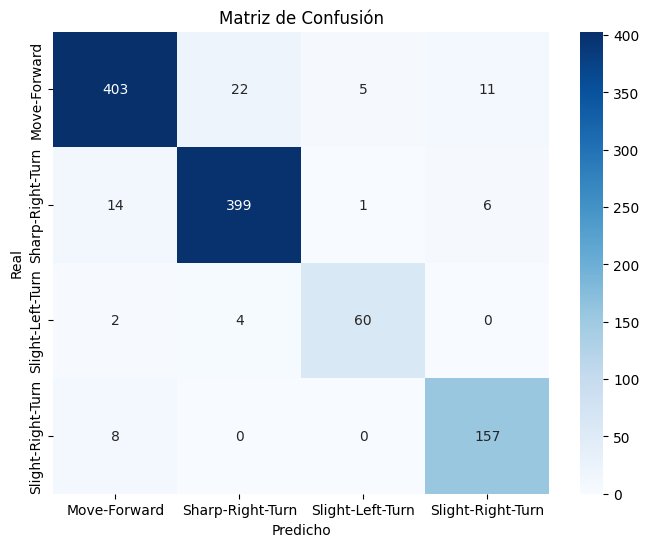

In [14]:
# 7. Matriz de confusión
cm = tf.math.confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

<p>Lo que estoy haciendo aqui es lo seguiente:<p>

<p>Muestra la matriz de confusión para analizar los errores del modelo.<p>

<h1>8. Curva de pérdida<h1>

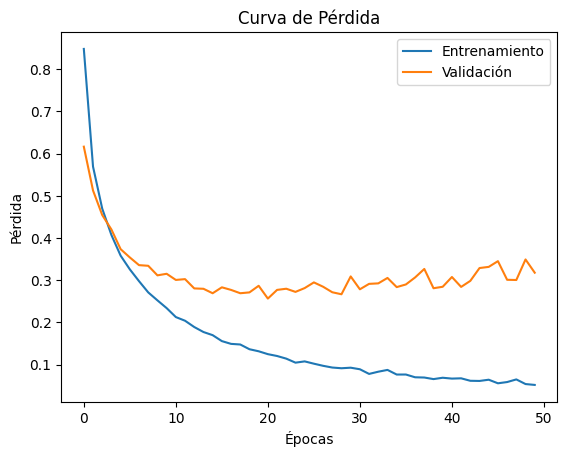

In [15]:
# 8. Curva de pérdida
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title("Curva de Pérdida")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.legend()
plt.show()

<p>Lo que estoy haciendo aqui es lo seguiente:<p>

<p>Muestra cómo la pérdida disminuye a lo largo del entrenamiento (idealmente debe bajar).<p>

<h1>Guardar modelo<h1>

In [16]:
# 9. Guardar modelo
model.save('modelo_sensores.h5')

# 📌 Conclusión  

Este código utiliza **TensorFlow y Keras** en lugar de Scikit-Learn para entrenar una red neuronal en datos de sensores.  

## ✅ Puntos clave:  
- **Arquitectura:** Dos capas ocultas (`100` y `50` neuronas, activación `ReLU`).  
- **Optimización:** Optimizador `Adam` con `learning_rate=0.001`.  
- **Evaluación:** Precisión en test, matriz de confusión y curva de pérdida.  
- **Guardado:** Se almacena el modelo entrenado en `"modelo_sensores.h5"`.  

## 🚀 Recomendaciones:  
- Aumentar las capas o neuronas si el modelo no es lo suficientemente preciso.  
- Ajustar la tasa de aprendizaje (`learning_rate`) si la curva de pérdida no converge bien.  
- Usar **KerasTuner** para encontrar hiperparámetros óptimos.  

**Este flujo permite entrenar un modelo de redes neuronales de manera eficiente y escalable.** 🔥  
